# Rolling Mean & Rolling Variance Plots in Python

We'll use a sample time-series (you can replace it with your own dataset).

## Basic Rolling Mean & Rolling Variance

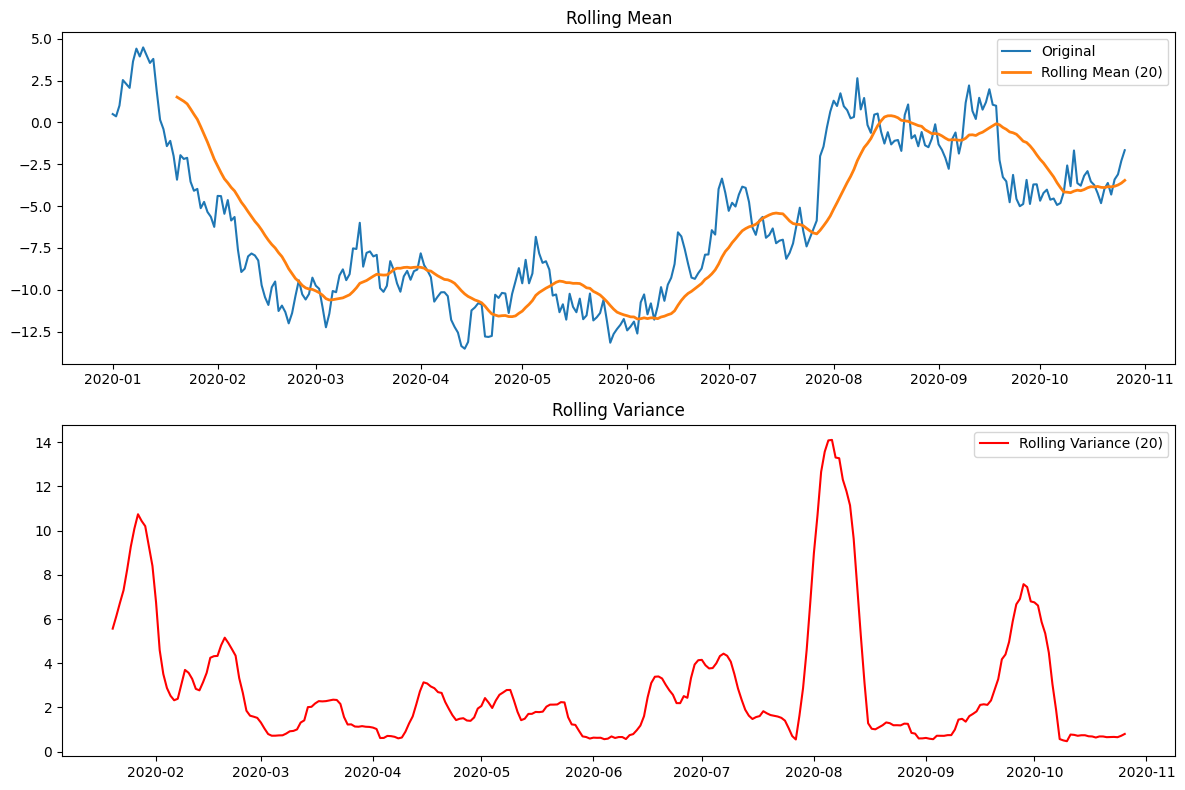

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create sample time-series data
np.random.seed(42)
dates = pd.date_range(start="2020-01-01", periods=300)
data = np.random.normal(loc=0, scale=1, size=300).cumsum()  # cumulative series

df = pd.DataFrame({"value": data}, index=dates)

# Compute rolling stats
df["rolling_mean"] = df["value"].rolling(window=20).mean()
df["rolling_var"]  = df["value"].rolling(window=20).var()

# Plot
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(df["value"], label="Original")
ax[0].plot(df["rolling_mean"], label="Rolling Mean (20)", linewidth=2)
ax[0].set_title("Rolling Mean")
ax[0].legend()

ax[1].plot(df["rolling_var"], label="Rolling Variance (20)", color="red")
ax[1].set_title("Rolling Variance")
ax[1].legend()

plt.tight_layout()
plt.show()


## Multiple Window Comparison (10, 20, 50)

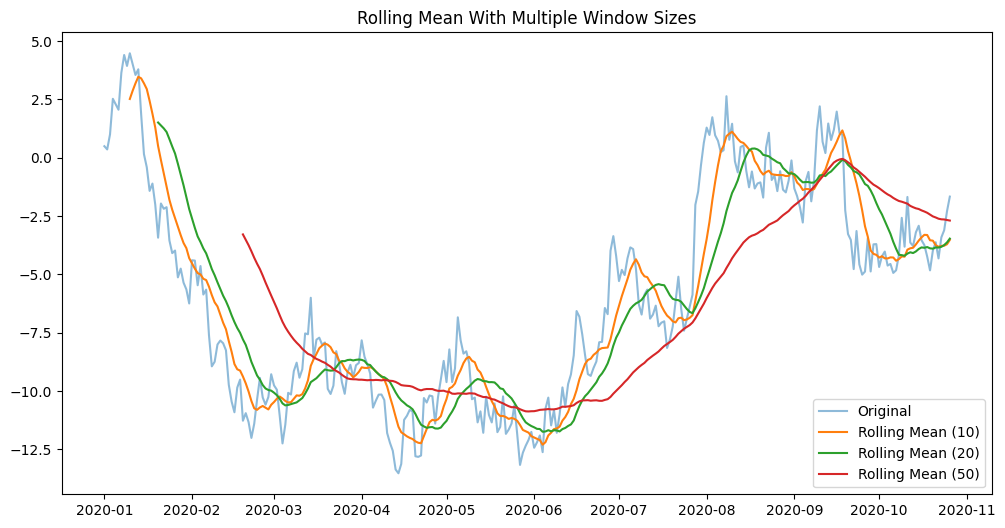

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df["value"], label="Original", alpha=0.5)

for w in [10, 20, 50]:
    plt.plot(df["value"].rolling(window=w).mean(), label=f"Rolling Mean ({w})")

plt.title("Rolling Mean With Multiple Window Sizes")
plt.legend()
plt.show()


## Rolling STD + Rolling Variance

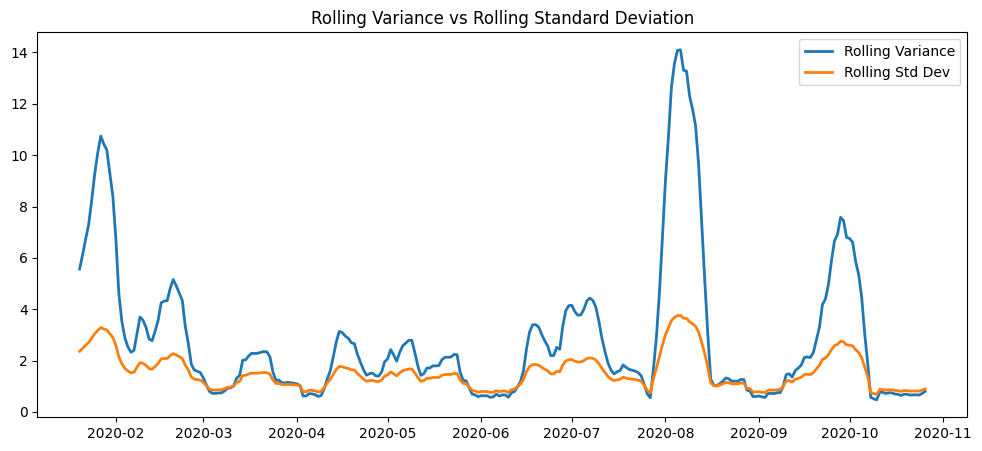

In [4]:
df["rolling_std"] = df["value"].rolling(20).std()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df["rolling_var"], label="Rolling Variance", linewidth=2)
ax.plot(df["rolling_std"], label="Rolling Std Dev", linewidth=2)

ax.set_title("Rolling Variance vs Rolling Standard Deviation")
ax.legend()
plt.show()


## Rolling Mean + Variance in One Plot (Dual Axis)

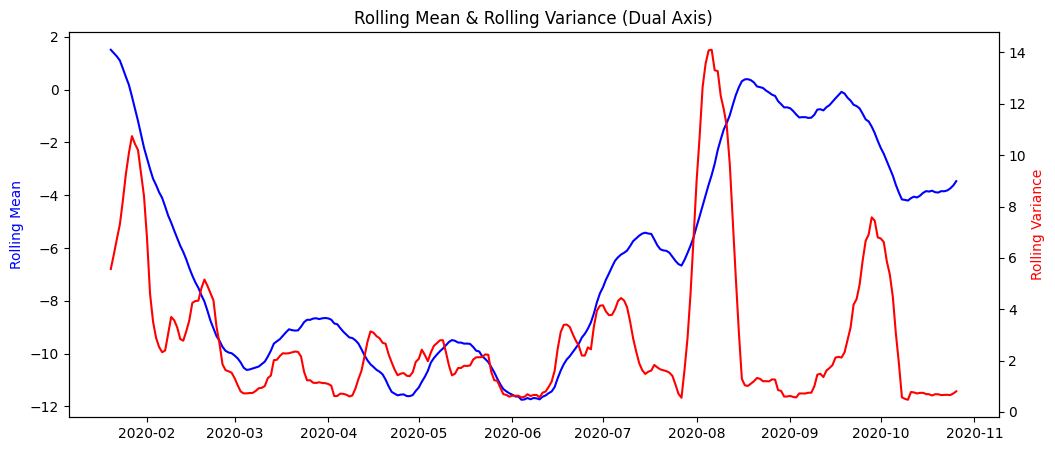

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df["rolling_mean"], color="blue", label="Rolling Mean")
ax1.set_ylabel("Rolling Mean", color="blue")

ax2 = ax1.twinx()
ax2.plot(df["rolling_var"], color="red", label="Rolling Variance")
ax2.set_ylabel("Rolling Variance", color="red")

plt.title("Rolling Mean & Rolling Variance (Dual Axis)")
plt.show()


## Rolling Mean on Multiple Columns (If you have a multivariate dataset)

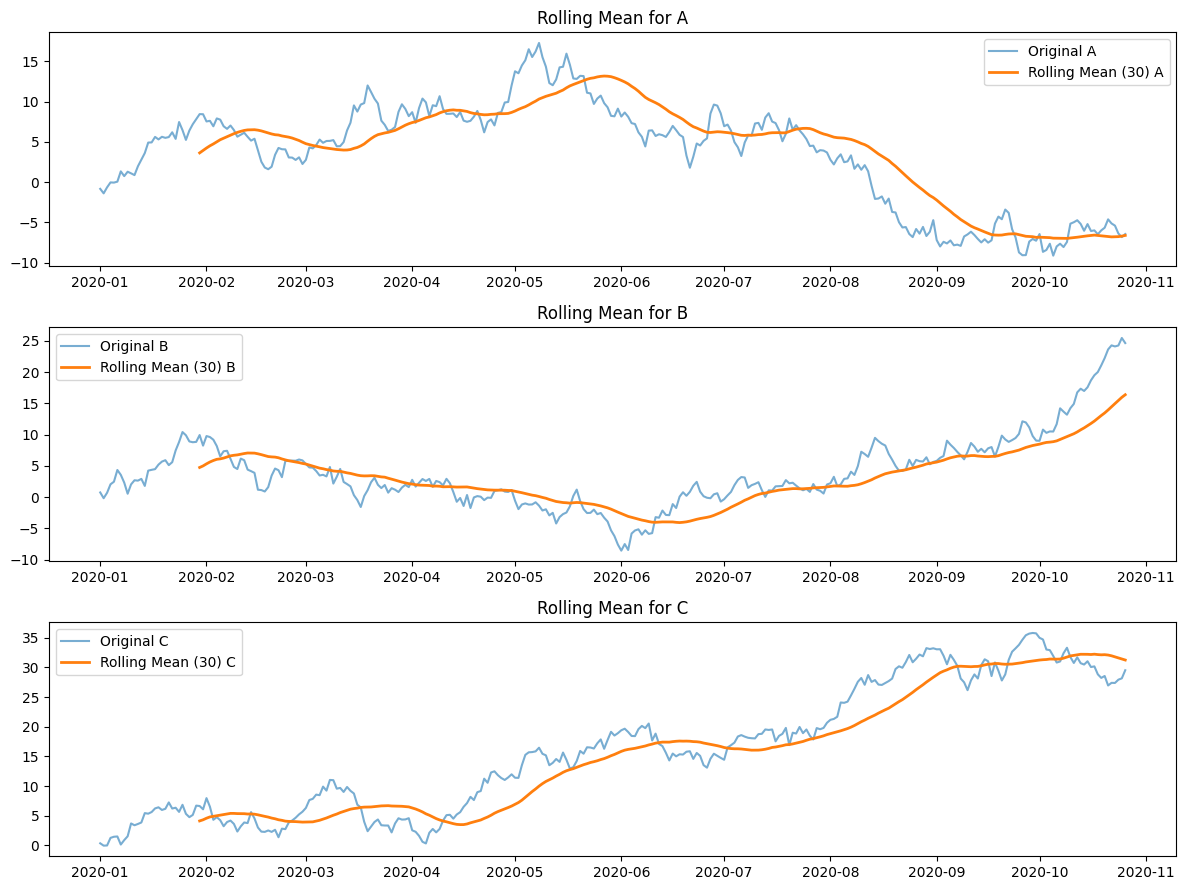

In [6]:
# Create sample multivariate dataset
df2 = pd.DataFrame({
    "A": np.random.randn(300).cumsum(),
    "B": np.random.randn(300).cumsum(),
    "C": np.random.randn(300).cumsum()
}, index=dates)

rolling_df = df2.rolling(30).mean()

fig, axs = plt.subplots(3, 1, figsize=(12, 9))

for i, col in enumerate(df2.columns):
    axs[i].plot(df2[col], label=f"Original {col}", alpha=0.6)
    axs[i].plot(rolling_df[col], label=f"Rolling Mean (30) {col}", linewidth=2)
    axs[i].legend()
    axs[i].set_title(f"Rolling Mean for {col}")

plt.tight_layout()
plt.show()
